# LLM-Augmented Test Analysis - Interactive Demo

This notebook demonstrates all features available in the Streamlit UI (`app_llm_demo.py`), adapted for Jupyter.

**Features (matching Streamlit UI):**
- **Chat Analysis** — Ask questions in natural language with MCP tool integration
- **Deep Dive** — Analyze specific tests with classifier prediction + LLM insights
- **Baseline Comparison** — Compare test results against baseline performance
- **Report Generation** — PO Sign-Off, Dev/QA, Stakeholder, Summary reports (anti-hallucination)
- **Test Comparison** — Compare two tests side-by-side with predictions
- **Visualizations** — Charts with LLM interpretation

**Setup:** Make sure your `.env` file has:
- `LLM_MODE=work` or `academic`
- LLM credentials (OPENAI_API_KEY or WORK_LLM_* variables)
- Database credentials (if using work mode)

In [ ]:
# Setup - Run this first
import sys
from pathlib import Path
import os

# Ensure we're in the project root directory (not notebooks/)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"📂 Working directory: {os.getcwd()}")

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

# Load environment
from dotenv import load_dotenv
load_dotenv(Path('.env'))

# Default to academic mode if not set
if 'LLM_MODE' not in os.environ:
    os.environ['LLM_MODE'] = 'academic'

# Import our components
from src.analyzer import TestAnalyzer
from src.data_source import get_data_source
from src.llm_provider import get_llm_provider

# Import centralized prompts (same as Streamlit UI)
from prompts.report_prompts import (
    get_summary_prompt_with_data,
    get_po_report_prompt_with_data,
    get_dev_report_prompt_with_data,
    get_stakeholder_report_prompt_with_data,
    get_test_comparison_prompt,
    format_critical_transactions_list,
    format_transaction_table,
    format_qa_table
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Setup complete!")
print(f"   Mode: {os.getenv('LLM_MODE', 'academic')}")


📂 Working directory: /Users/sailaw864@cable.comcast.com/Desktop/Drexel/INFO629/Assignments/A3_Code
✅ Setup complete!
   Mode: work


## 1. Initialize Components

Load the TestAnalyzer, data source, and LLM provider.

In [5]:
# Initialize analyzer (combines data + LLM + classifier)
analyzer = TestAnalyzer()

# Direct access to components
data_source = analyzer.data_source
llm = analyzer.llm
model = analyzer.model

print("✅ TestAnalyzer initialized")
print(f"   Data source: {data_source.__class__.__name__}")
print(f"   LLM: {llm.__class__.__name__}")
print(f"   Classifier: {model.__class__.__name__}")

🔧 Initializing TestAnalyzer in WORK mode...
💼 Initializing WORK mode (LLM Gateway)
   ✅ LLM: WorkGatewayProvider
💼 Initializing WORK mode (PostgreSQL data source)
✅ PostgreSQL connection verified
   ✅ Data: PostgresDataSource
   ✅ Classifier: RandomForestClassifier
✅ TestAnalyzer ready

✅ TestAnalyzer initialized
   Data source: PostgresDataSource
   LLM: WorkGatewayProvider
   Classifier: RandomForestClassifier


## 2. Load and Explore Data

Get an overview of available tests.

In [6]:
# Load all test data
df = data_source.load_test_data()

print(f"📊 Dataset Overview:")
print(f"   Total rows: {len(df):,}")
print(f"   Unique tests: {df['testplan'].nunique()}")
print(f"   Unique transactions: {df['transaction_name'].nunique()}")
print(f"   Date range: {df['end_time'].min()} to {df['end_time'].max()}")
print(f"\n   Exit codes: {sorted(df['exit_code'].unique())}")

# Show sample
df.head()

🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests
📊 Dataset Overview:
   Total rows: 35,118
   Unique tests: 714
   Unique transactions: 107
   Date range: 2022-09-07 14:32:11.001381-07:00 to 2026-03-03 23:09:31.482435-08:00

   Exit codes: [np.int64(1), np.int64(2), np.int64(3)]


,testplan,run_id,transaction_name,request_type,txn_requests,txn_failed,error_percentage,avg_response_time,min_response_time,max_response_time,median_response_time,perc_95,perc_99,exit_code,num_clients,rps_avg,resp_time_avg,fail_ratio,build_version,total_requests,end_time
0,LoadTest_20260304T060726Z,2026-03-03 22:09:29.217235-08:00,/auth/login,POST,1764,0,0.0,79.321369,10.441788,5071.199667,66.234384,149.215150,366.233353,1,2000,890.924432,66.246006,0.000711,Chat Web App Deploy_20260303.2_20260303.2,3205349,2026-03-03 23:09:31.482435-08:00
1,LoadTest_20260304T060726Z,2026-03-03 22:09:29.217235-08:00,/auth/logout,POST,1370,0,0.0,71.235650,10.897913,695.126398,66.449820,148.420664,251.608723,1,2000,890.924432,66.246006,0.000711,Chat Web App Deploy_20260303.2_20260303.2,3205349,2026-03-03 23:09:31.482435-08:00
2,LoadTest_20260304T060726Z,2026-03-03 22:09:29.217235-08:00,/auth/relogin,POST,418,0,0.0,67.675889,10.333480,435.515754,64.150360,135.051476,248.161839,1,2000,890.924432,66.246006,0.000711,Chat Web App Deploy_20260303.2_20260303.2,3205349,2026-03-03 23:09:31.482435-08:00
3,LoadTest_20260304T060726Z,2026-03-03 22:09:29.217235-08:00,/auth/verifysession,POST,4044,0,0.0,73.104506,9.821158,5065.432926,65.976401,145.380263,281.515366,1,2000,890.924432,66.246006,0.000711,Chat Web App Deploy_20260303.2_20260303.2,3205349,2026-03-03 23:09:31.482435-08:00
4,LoadTest_20260304T060726Z,2026-03-03 22:09:29.217235-08:00,/client/negotiate?hub=agentchatrequest,POST,2000,0,0.0,52.730132,31.295906,5061.358347,40.805062,73.752265,140.386597,1,2000,890.924432,66.246006,0.000711,Chat Web App Deploy_20260303.2_20260303.2,3205349,2026-03-03 23:09:31.482435-08:00


In [7]:
# Get test summary
test_summary = df.groupby(['testplan', 'exit_code']).agg({
    'transaction_name': 'count',
    'error_percentage': 'mean',
    'perc_95': 'mean',
    'avg_response_time': 'mean'
}).rename(columns={'transaction_name': 'num_transactions'})

test_summary = test_summary.reset_index()
test_summary['result'] = test_summary['exit_code'].map({1: 'PASS', 2: 'FAIL', 3: 'FAIL', 4: 'FAIL'})

print("📋 Test Summary:")
print(test_summary.head(10))

📋 Test Summary:
                    testplan  exit_code  num_transactions  error_percentage  \
0  LoadTest_20220907T202825Z          3                46          0.000365   
1  LoadTest_20220914T165432Z          3                46          0.000000   
2  LoadTest_20220915T201936Z          3                46          0.009418   
3  LoadTest_20220919T100939Z          3                46          0.012269   
4  LoadTest_20220923T145805Z          1                46          0.000000   
5  LoadTest_20220929T195338Z          1                46          0.014717   
6  LoadTest_20221013T133828Z          3                46          2.233578   
7  LoadTest_20221013T151613Z          1                46          0.000827   
8  LoadTest_20221014T114553Z          1                46          0.001394   
9  LoadTest_20221014T214830Z          1                46          0.004919   

      perc_95  avg_response_time result  
0  503.238924         166.306917   FAIL  
1  444.205705         155.5264

## 3. Interactive Q&A with MCP Tool Integration

The `analyzer.ask()` method automatically routes questions to MCP tools (query_tests, get_test_details, compare_baseline, predict_test) and fetches real data before sending to LLM.

This is the same unified method used by the Streamlit UI.

In [8]:
# Conversation history (shared across all helpers)
conversation_history = []

def ask_question(question: str):
    """
    Ask a question about test data using MCP tool integration.
    Same as the Chat Analysis page in Streamlit UI.
    
    Automatically:
    - Routes to MCP tools (query_tests, get_test_details, etc.)
    - Fetches real data from database
    - Maintains conversation context
    
    Args:
        question: Your question in natural language
    
    Examples:
        ask_question("What are the last 5 test runs?")
        ask_question("Show me all failed tests")
        ask_question("What is the overall pass rate?")
    """
    print(f"🤔 Question: {question}")
    print("   🤖 Processing with MCP tools...")
    
    result = analyzer.ask(
        question,
        conversation_history=conversation_history
    )
    
    answer = result['answer']
    tools_used = result.get('tools_used', [])
    tokens = result.get('tokens_used', 'N/A')
    
    # Save to history
    conversation_history.append((question, answer))
    
    # Display
    print(f"\n💡 Answer:")
    print(answer)
    
    if tools_used:
        print(f"\n   🔧 Tools used: {', '.join(tools_used)}")
    print(f"   💭 Tokens: {tokens}")
    print(f"   📝 Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return answer

print("✅ ask_question() loaded — uses analyzer.ask() with MCP tool integration")
print("\nExamples:")
print('   ask_question("What are the last 5 test runs?")')
print('   ask_question("Show me all failed tests")')
print('   ask_question("What is the overall pass rate?")')

✅ ask_question() loaded — uses analyzer.ask() with MCP tool integration

Examples:
   ask_question("What are the last 5 test runs?")
   ask_question("Show me all failed tests")
   ask_question("What is the overall pass rate?")


In [9]:
# Helper to ask about a specific test (anti-hallucination: fetches real test data)
def ask_about_test(test_id_or_index, question):
    """
    Ask a question about a specific test.
    Uses analyzer.ask(about_test=...) which fetches real test data
    to prevent LLM hallucination — same as Deep Dive in Streamlit UI.
    
    Args:
        test_id_or_index: Test index (0-N) or testplan ID string
        question: Your question about the test
    
    Example:
        ask_about_test(0, "What are the slowest transactions?")
        ask_about_test("LoadTest_20260304T060726Z", "Why did this test fail?")
    """
    print(f"🔍 Analyzing test: {test_id_or_index}")
    print(f"🤔 Question: {question}")
    print("   🤖 Fetching real test data + sending to LLM...")
    
    result = analyzer.ask(
        question,
        about_test=test_id_or_index,
        conversation_history=conversation_history
    )
    
    answer = result['answer']
    tokens = result.get('tokens_used', 'N/A')
    
    # Save to history
    conversation_history.append((question, answer))
    
    # Display
    print(f"\n💡 Answer:")
    print(answer)
    print(f"\n   💭 Tokens: {tokens}")
    print(f"   📝 Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return answer

print("✅ ask_about_test() loaded — uses analyzer.ask(about_test=...) with real data")
print("   Anti-hallucination: real test context is fetched before LLM sees the question")

✅ ask_about_test() loaded — uses analyzer.ask(about_test=...) with real data
   Anti-hallucination: real test context is fetched before LLM sees the question


In [10]:
# NEW: Helper for data-driven questions (like "last 3 tests", aggregations, etc.)
def ask_with_data(query_result, question):
    """
    Ask LLM to interpret pandas query results or any data.
    Uses analyzer.ask_about_data() - works in both Streamlit and Jupyter.
    
    Args:
        query_result: Pandas DataFrame, Series, or formatted string
        question: Your question about the data
    
    Example:
        # Get last 3 tests
        last_3 = df.groupby("testplan").agg({
            "end_time": "first",
            "exit_code": "first",
            "transaction_name": "count"
        }).sort_values("end_time", ascending=False).head(3)
        
        ask_with_data(last_3, "What are the last 3 test runs?")
    """
    # Convert DataFrame/Series to string if needed
    if hasattr(query_result, "to_string"):
        data_str = query_result.to_string()
    else:
        data_str = str(query_result)
    
    # Use analyzer's ask_about_data method
    result = analyzer.ask_about_data(
        data_context=data_str,
        question=question,
        conversation_history=conversation_history
    )
    
    # Display
    print(f"🤔 Question: {question}")
    print(f"\n💡 Answer:")
    print(result["answer"])
    print(f"\n   Tokens used: {result["tokens_used"] or 'N/A'}")
    
    # Save to history
    conversation_history.append((question, result["answer"]))
    print(f"   Conversation depth: {len(conversation_history)} exchanges")
    print("-" * 80)
    
    return result["answer"]

print("✅ ask_with_data() helper loaded!")
print("   Uses analyzer.ask_about_data() - works with any pandas query")
print("\nExamples:")
print("   last_3 = df.groupby('testplan')['end_time'].first().sort_values().tail(3)")
print("   ask_with_data(last_3, 'What are the last 3 test runs?')")


✅ ask_with_data() helper loaded!
   Uses analyzer.ask_about_data() - works with any pandas query

Examples:
   last_3 = df.groupby('testplan')['end_time'].first().sort_values().tail(3)
   ask_with_data(last_3, 'What are the last 3 test runs?')


## 4. Ask Your Questions!

Now you can ask questions interactively. MCP tools automatically fetch real data from the database.

```python
# MCP-powered queries (fetch real data automatically)
ask_question("What are the last 5 test runs?")
ask_question("Show me all failed tests")
ask_question("What is the overall pass rate?")

# Test-specific analysis (anti-hallucination with real data)
ask_about_test(0, "What are the slowest transactions?")
ask_about_test("LoadTest_20260304T060726Z", "Why did this test fail?")

# Data-driven analysis (pandas + LLM)
ask_with_data(df.describe(), "What patterns do you see in this data?")
```

In [11]:
# Example 1: MCP-powered query — fetches real test data from database
ask_question("What are the last 5 test runs and their results?")

🤔 Question: What are the last 5 test runs and their results?
   🤖 Processing with MCP tools...
🤔 Analyzing question: 'What are the last 5 test runs and their results?'
   💡 Tool plan: The user is asking for the last 5 test runs and their results. No specific test IDs are mentioned, and there is no relevant conversation history. Therefore, I need to fetch the most recent 5 tests using query_tests with limit=5 and sort_by='end_time'.
   🔧 Calling query_tests({'limit': 5, 'sort_by': 'end_time', 'ascending': False})
      ↳ Reusing data source connection (no new DB connection)
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 u

'Here are the last 5 test runs and their results:\n\n| Test Name                  | P95   | Errors  | Txns | Result | End Time                        |\n|----------------------------|-------|---------|------|--------|----------------------------------|\n| LoadTest_20260304T060726Z  | 662ms | 0.0%    | 54   | PASS   | 2026-03-03 23:09:31.482435-08:00|\n| LoadTest_20260302T113608Z  | 710ms | 0.0%    | 54   | PASS   | 2026-03-02 04:38:24.516272-08:00|\n| LoadTest_20260302T051326Z  | 673ms | 0.0%    | 54   | PASS   | 2026-03-01 22:18:28.341968-08:00|\n| LoadTest_20260227T124410Z  | 721ms | 0.1%    | 54   | PASS   | 2026-02-27 05:46:14.138698-08:00|\n| LoadTest_20260227T060941Z  | 60334ms| 12.6%  | 59   | FAIL   | 2026-02-26 23:11:44.887112-08:00|\n\n**Key patterns and insights:**\n- The most recent 4 runs all passed, with P95 latency between 662ms and 721ms, and error rates at or near 0%.\n- There was a major failure in the 5th most recent run: P95 latency spiked to 60.3 seconds (60334ms) 

In [12]:
# Example 2: Ask about failures — MCP tools fetch failure data automatically
ask_question("What patterns do you see in failed tests?")

🤔 Question: What patterns do you see in failed tests?
   🤖 Processing with MCP tools...
🤔 Analyzing question: 'What patterns do you see in failed tests?'
   💡 Tool plan: The user is asking about patterns in failed tests, which requires fetching data about recent failed test runs. Since no specific test IDs are mentioned for analysis, the best approach is to retrieve a list of recent failed tests using query_tests with exit_code=2 (FAIL). This will provide the necessary data to analyze for patterns.
   🔧 Calling query_tests({'limit': 10, 'exit_code': 2, 'sort_by': 'end_time', 'ascending': False})
      ↳ Reusing data source connection (no new DB connection)
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
 

'Here are the last 10 failed test runs:\n\n| Test Name                  | P95     | Errors  | Txns | Result | End Time                        |\n|----------------------------|---------|---------|------|--------|----------------------------------|\n| LoadTest_20251029T235333Z  | 4545ms  | 11.5%   | 52   | FAIL   | 2025-10-29 18:01:16.477571-07:00|\n| LoadTest_20251028T160956Z  | 8228ms  | 4.9%    | 49   | FAIL   | 2025-10-28 10:12:44.664177-07:00|\n| LoadTest_20251025T183410Z  | 20276ms | 39.2%   | 62   | FAIL   | 2025-10-25 23:37:23.942998-07:00|\n| LoadTest_20251025T164047Z  | 5241ms  | 5.3%    | 49   | FAIL   | 2025-10-25 11:13:00.813687-07:00|\n| LoadTest_20251024T221051Z  | 1829ms  | 8.1%    | 51   | FAIL   | 2025-10-24 16:13:43.029611-07:00|\n| LoadTest_20251024T020925Z  | 673ms   | 13.1%   | 54   | FAIL   | 2025-10-24 05:11:46.815428-07:00|\n| LoadTest_20251023T205612Z  | 24195ms | 28.1%   | 65   | FAIL   | 2025-10-23 14:58:11.294329-07:00|\n| LoadTest_20251023T104115Z  | 581ms  

In [13]:
# Example 3: Test-specific analysis (anti-hallucination: real data is fetched)
ask_about_test(0, "What are the slowest transactions and why might they be slow?")

🔍 Analyzing test: 0
🤔 Question: What are the slowest transactions and why might they be slow?
   🤖 Fetching real test data + sending to LLM...
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests

💡 Answer:
**Key Findings: Slowest Transactions**

Here are the slowest transactions from the test, sorted by P95 response time:

| Transaction Name                                          | P95 (ms)   | Average (ms) | Error Rate |
|----------------------------------------------------------|------------|--------------|------------|
| AuthPath_step_001_Launch                                 | 1902.79    | 1796.29      | 0

'**Key Findings: Slowest Transactions**\n\nHere are the slowest transactions from the test, sorted by P95 response time:\n\n| Transaction Name                                          | P95 (ms)   | Average (ms) | Error Rate |\n|----------------------------------------------------------|------------|--------------|------------|\n| AuthPath_step_001_Launch                                 | 1902.79    | 1796.29      | 0.00%      |\n| BAPIS_Pickup_Step_001_Launch_EnterPasscode               | 1901.28    | 1796.54      | 0.00%      |\n| BAPIS_UnPack_Step_001_ScanBag_Launch                     | 1887.67    | 1793.34      | 0.00%      |\n| BAPIS_ScanandPack_Step_001_Launch                        | 1866.40    | 1796.36      | 0.00%      |\n| AuthPath_step_003_Search_AccountNum                      | 1835.13    | 1742.40      | 0.00%      |\n| AuthPath_step_005_SelectVerificationMethod_AccountNum    | 1823.75    | 1741.26      | 0.00%      |\n| AuthPath_step_004_Select_NameForAuthenticate     

## 5. Deep Dive: Analyze Specific Test

Pick a test and get comprehensive analysis — same as the **Deep Dive** page in the Streamlit UI.

Uses `analyzer.analyze_test()` which fetches real test data to prevent hallucination.

In [14]:
# List available tests with their results
tests = data_source.list_tests(limit=20)
print("Available tests:")
for i, test in enumerate(tests[:10], 1):
    result = df[df['testplan'] == test]['exit_code'].iloc[0]
    result_str = "✅ PASS" if result == 1 else "❌ FAIL"
    print(f"  {i}. {test} — {result_str}")

if len(tests) > 10:
    print(f"  ... and {len(tests) - 10} more")

print("\nTo analyze: analyzer.analyze_test('TEST_ID_HERE')")
print("To ask about: ask_about_test(0, 'What are the key findings?')")

Available tests:
  1. LoadTest_20260304T060726Z — ✅ PASS
  2. LoadTest_20260302T113608Z — ✅ PASS
  3. LoadTest_20260302T051326Z — ✅ PASS
  4. LoadTest_20260227T124410Z — ✅ PASS
  5. LoadTest_20260227T060941Z — ❌ FAIL
  6. LoadTest_20260226T061000Z — ✅ PASS
  7. LoadTest_20260224T060541Z — ✅ PASS
  8. LoadTest_20260219T062336Z — ✅ PASS
  9. LoadTest_20260217T170301Z — ✅ PASS
  10. LoadTest_20260217T124120Z — ✅ PASS
  ... and 10 more

To analyze: analyzer.analyze_test('TEST_ID_HERE')
To ask about: ask_about_test(0, 'What are the key findings?')


In [15]:
# Deep dive analysis on a specific test
test_to_analyze = tests[0]  # Change index or use specific ID
print(f"🔍 Deep Dive: {test_to_analyze}\n")

# Full LLM analysis (same as Streamlit Deep Dive page)
analysis = analyzer.analyze_test(test_to_analyze, include_transactions=True)
print(analysis)

# Follow-up question about this test
ask_about_test(test_to_analyze, "What is the most concerning finding and what should we investigate?")

🔍 Deep Dive: LoadTest_20260304T060726Z

🔍 Analyzing test: LoadTest_20260304T060726Z
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading baselines from models/baselines.pkl...
  Loaded 179 baseline groups

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
 

'### Most Concerning Finding\n\nThe most concerning finding is the **high P95 response times (1.8–1.9 seconds)** for all initial authentication and launch-related transactions:\n\n| Transaction Name                                          | P95 (ms)   | Average (ms) | Error Rate |\n|----------------------------------------------------------|------------|--------------|------------|\n| AuthPath_step_001_Launch                                 | 1902.79    | 1796.29      | 0.00%      |\n| BAPIS_Pickup_Step_001_Launch_EnterPasscode               | 1901.28    | 1796.54      | 0.00%      |\n| BAPIS_UnPack_Step_001_ScanBag_Launch                     | 1887.67    | 1793.34      | 0.00%      |\n| BAPIS_ScanandPack_Step_001_Launch                        | 1866.40    | 1796.36      | 0.00%      |\n| AuthPath_step_003_Search_AccountNum                      | 1835.13    | 1742.40      | 0.00%      |\n| AuthPath_step_005_SelectVerificationMethod_AccountNum    | 1823.75    | 1741.26      | 0.00%    

## 6. Compare Tests

Compare two tests to understand differences — same as the **Compare Tests** page in Streamlit UI.

Two comparison methods available:
1. **analyzer.compare_tests()** — High-level comparison using LLM
2. **get_test_comparison_prompt()** — Focused comparison with top performers and common transaction analysis (optimized to avoid timeout)


In [16]:
# Find a PASS and FAIL test for comparison
pass_test = None
fail_test = None

for test in tests[:20]:
    result = df[df['testplan'] == test]['exit_code'].iloc[0]
    if result == 1 and pass_test is None:
        pass_test = test
    elif result != 1 and fail_test is None:
        fail_test = test
    
    if pass_test and fail_test:
        break

print(f"PASS test: {pass_test}")
print(f"FAIL test: {fail_test}")

PASS test: LoadTest_20260304T060726Z
FAIL test: LoadTest_20260227T060941Z


In [ ]:
# Method 1: Simple comparison using analyzer.compare_tests()
if pass_test and fail_test:
    comparison = analyzer.compare_tests(pass_test, fail_test)
    print("=" * 80)
    print("METHOD 1: High-Level Comparison")
    print("=" * 80)
    print(comparison)
    print()
else:
    print("Need both PASS and FAIL tests for comparison")


🔍 Comparing tests:
   Test 1: LoadTest_20260304T060726Z
   Test 2: LoadTest_20260227T060941Z
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading baselines from models/baselines.pkl...
  Loaded 179 baseline groups

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinc

In [ ]:
# Method 2: Optimized comparison with focused transaction data
# Uses get_test_comparison_prompt() from prompts/report_prompts.py
# Shows: top 10 slowest, common transaction regressions/improvements
# Optimized to avoid timeout by focusing on key insights instead of ALL transactions

if pass_test and fail_test:
    # Get test data
    df_test1 = analyzer.data_source.get_test_by_id(pass_test)
    df_test2 = analyzer.data_source.get_test_by_id(fail_test)
    
    # Build optimized comparison prompt
    comparison_prompt = get_test_comparison_prompt(
        pass_test, fail_test, df_test1, df_test2
    )
    
    # Send to LLM
    print("=" * 80)
    print("METHOD 2: Optimized Focused Comparison")
    print("=" * 80)
    result = analyzer.ask(comparison_prompt, conversation_history=conversation_history)
    print(result['answer'])
    print(f"\n   💭 Tokens: {result.get('tokens_used', 'N/A')}")
    conversation_history.append((f"Compare {pass_test} vs {fail_test}", result['answer']))
else:
    print("Need both PASS and FAIL tests for comparison")


## 7. Baseline Comparison

Compare a test against the classifier's baseline data — shows how each transaction deviates from the
median of passing runs. Same data used by the ML classifier for feature engineering.

Uses `get_baseline_comparison()` from `mcp_server/tools/baseline.py`.

**Mode-Aware Loading:**
- **Academic Mode** (`LLM_MODE=academic`): Uses `baselines_anonymized.pkl` with sanitized transaction names (API_001, Auth_001, etc.)
- **Work Mode** (`LLM_MODE=work`): Uses `baselines.pkl` with original transaction names

The baseline tool automatically loads the correct file based on your environment.


In [18]:
from mcp_server.tools.baseline import get_baseline_comparison

# Compare latest test against baseline
test_for_baseline = tests[0]  # Change to any test ID
print(f"📊 Baseline Comparison: {test_for_baseline}\n")

baseline_result = get_baseline_comparison(test_for_baseline, analyzer=analyzer)

if 'error' in baseline_result:
    print(f"❌ {baseline_result['error']}")
else:
    summary = baseline_result['summary']
    print(f"Test Type: {summary['test_type']} | Clients: {summary['num_clients']} | Result: {summary['result']}")
    print(f"Transactions: {summary['total_transactions']} total, {summary['transactions_with_baseline']} with baseline")
    
    if 'avg_p95_deviation_pct' in summary:
        print(f"\n📈 Deviation Summary:")
        print(f"   Avg P95 deviation: {summary['avg_p95_deviation_pct']:.1f}%")
        print(f"   Max P95 deviation: {summary['max_p95_deviation_pct']:.1f}%")
        print(f"   Avg error delta:   {summary['avg_error_delta']:.2f}%")
        print(f"   Critical (>50%):   {summary.get('critical_deviations_count', 0)} txns")
        print(f"   Degraded (20-50%): {summary.get('degraded_deviations_count', 0)} txns")
    
    # Show worst deviations
    with_baseline = [t for t in baseline_result['transactions'] if t['has_baseline']]
    if with_baseline:
        worst = sorted(with_baseline, key=lambda t: abs(t['deviation']['p95_pct']), reverse=True)[:5]
        print(f"\n🔥 Top 5 Largest P95 Deviations:")
        for t in worst:
            dev = t['deviation']['p95_pct']
            arrow = "↑" if dev > 0 else "↓"
            print(f"   {t['name']}: {t['actual']['p95']:.0f}ms vs {t['baseline']['p95']:.0f}ms baseline ({arrow}{abs(dev):.1f}%)")

📊 Baseline Comparison: LoadTest_20260304T060726Z

🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests
Test Type: load_test | Clients: 2000 | Result: PASS
Transactions: 54 total, 54 with baseline

📈 Deviation Summary:
   Avg P95 deviation: -0.4%
   Max P95 deviation: 268.5%
   Avg error delta:   0.00%
   Critical (>50%):   4 txns
   Degraded (20-50%): 1 txns

🔥 Top 5 Largest P95 Deviations:
   /fixagent/getprofanityblacklist: 1034ms vs 281ms baseline (↑268.5%)
   /negotiate: 626ms vs 214ms baseline (↑193.3%)
   /fixagent/getscripts: 1042ms vs 436ms baseline (↑139.3%)
   /fixagent/getcustomscripts: 1058ms vs 619ms 

## 8. Classifier Prediction

Get the ML classifier's prediction for any test — same as the prediction display in Streamlit UI.

Shows PASS/FAIL prediction with confidence score. Confidence values < 2 are treated as decimals
and converted to percentages.

In [19]:
# Get classifier prediction for a test
test_for_prediction = tests[0]  # Change to any test ID
print(f"🤖 Classifier Prediction: {test_for_prediction}\n")

pred = analyzer.predict_test(test_for_prediction)

# Confidence conversion (same as Streamlit UI)
confidence = pred['confidence']
if confidence is not None and confidence < 2:
    confidence = confidence * 100

result_emoji = "✅" if pred['prediction'] == "PASS" else "❌"
actual_emoji = "✅" if pred['actual_result'] == "PASS" else "❌"
match = "✓ Correct" if pred['prediction'] == pred['actual_result'] else "✗ Mismatch"

print(f"   Prediction:  {result_emoji} {pred['prediction']} ({confidence:.1f}% confidence)")
print(f"   Actual:      {actual_emoji} {pred['actual_result']}")
print(f"   Match:       {match}")
print(f"   Transactions: {pred['num_transactions']}")

# Show key features the classifier used
print(f"\n📊 Key Features (what the classifier sees):")
for feature, value in pred['features'].items():
    print(f"   {feature}: {value:.4f}")

🤖 Classifier Prediction: LoadTest_20260304T060726Z

🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests

=== Feature Engineering Pipeline ===

Step 1: Deriving test_type from build_version...
  load_test: 1 runs

Step 2: Loading baselines from models/baselines.pkl...
  Loaded 179 baseline groups

Step 3: Computing per-transaction % deviations...

Step 4: Aggregating to per-run feature vectors...
  Aggregated to 1 run-level feature vectors
    Pass: 1  Fail: 0
   Prediction:  ✅ PASS (99.5% confidence)
   Actual:      ✅ PASS
   Match:       ✓ Correct
   Transactions: 54

📊 Key Features (what the classifier sees):
 

## 9. Generate Reports

Generate the same 4 report types available in the Streamlit **Chat Analysis** page.
Each report pre-fetches real test data, baseline comparison, and classifier prediction
to prevent LLM hallucination (anti-hallucination pattern).

Report types:
- **Summary** — Quick overview with PASS/FAIL assessment
- **PO Report** — Product Owner release sign-off report
- **Dev Report** — Detailed engineering report with transaction-level data
- **Stakeholder Report** — Business-focused summary

In [ ]:
def generate_report(report_type: str, test_id: str = None):
    """
    Generate a report — same as the Streamlit UI report buttons.
    Pre-fetches real data to prevent hallucination.
    Uses centralized prompts from prompts/report_prompts.py.
    
    Args:
        report_type: 'summary', 'po_report', 'dev_report', or 'stakeholder_report'
        test_id: Test to report on (defaults to latest test)
    """
    valid_types = ['summary', 'po_report', 'dev_report', 'stakeholder_report']
    if report_type not in valid_types:
        print(f"❌ Invalid report type. Use one of: {valid_types}")
        return
    
    # Get test ID
    if test_id is None:
        test_id = tests[0]
    
    print(f"📊 Generating {report_type} for: {test_id}")
    print("   Fetching real data (anti-hallucination)...")
    
    # Pre-fetch all real data (same as Streamlit UI)
    baseline_result = get_baseline_comparison(test_id, analyzer=analyzer)
    pred_result = analyzer.predict_test(test_id)
    
    test_df = analyzer.data_source.get_test_by_id(test_id)
    test_summary = test_df.groupby('testplan').agg({
        'perc_95': 'mean',
        'error_percentage': 'mean',
        'transaction_name': 'count',
        'end_time': 'first',
        'exit_code': 'first'
    }).iloc[0]
    
    baseline_summary = baseline_result.get('summary', {}) if 'error' not in baseline_result else {}
    
    # Build report prompt using centralized functions (matches Streamlit UI)
    if report_type == 'summary':
        question = get_summary_prompt_with_data(
            test_id, test_summary, baseline_summary, pred_result
        )
    
    elif report_type == 'po_report':
        critical_list = format_critical_transactions_list(baseline_result)
        question = get_po_report_prompt_with_data(
            test_id, test_summary, baseline_summary, critical_list, pred_result
        )
    
    elif report_type == 'dev_report':
        txn_table = format_transaction_table(baseline_result)
        question = get_dev_report_prompt_with_data(
            test_id, txn_table, baseline_summary, pred_result
        )
    
    elif report_type == 'stakeholder_report':
        qa_table = format_qa_table(baseline_result)
        question = get_stakeholder_report_prompt_with_data(
            test_id, qa_table, baseline_summary, pred_result
        )
    
    # Send to LLM
    print("   🤖 Sending to LLM...")
    result = analyzer.ask(question, conversation_history=conversation_history)
    answer = result['answer']
    conversation_history.append((question, answer))
    
    print(f"\n{'='*80}")
    print(answer)
    print(f"{'='*80}")
    print(f"\n   💭 Tokens: {result.get('tokens_used', 'N/A')}")
    return answer

print("✅ generate_report() loaded — uses centralized prompts from prompts/report_prompts.py")
print("\nUsage:")
print('   generate_report("summary")           # Quick overview')
print('   generate_report("po_report")         # Product Owner sign-off')
print('   generate_report("dev_report")        # Engineering deep dive')
print('   generate_report("stakeholder_report") # Business summary')


✅ generate_report() loaded

Usage:
   generate_report("summary")           # Quick overview
   generate_report("po_report")          # Product Owner sign-off
   generate_report("dev_report")         # Engineering deep dive
   generate_report("stakeholder_report") # Business summary


In [22]:
# Example: Generate a summary report for the latest test
generate_report("po_report")

📊 Generating po_report for: LoadTest_20260304T060726Z
   Fetching real data (anti-hallucination)...
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests
🔍 Extracting data from PostgreSQL...
Extracting training data from database...
  Extracted 35,211 rows (714 distinct runs)
  Excluded 93 SignalR_Analysis meta-rows

  Summary:
    Total rows:          35,118
    Distinct runs:       714
    Distinct txn names:  107
    Pass (exit_code=1):  413 runs
    Fail (exit_code≠1):  302 runs
    Pass/Fail ratio:     1.4:1
    Avg txns per run:    49

✅ Loaded 35118 rows, 714 unique tests

=== Feature Engineering Pipeline ==

'**Release Sign-Off Report: LoadTest_20260304T060726Z**\n\n---\n\n**1. Executive Summary**  \nThe latest load test (ID: LoadTest_20260304T060726Z) completed on 2026-03-03 and achieved a PASS result, both through manual review and automated classification (99.5% confidence). Overall system performance met key targets with no errors observed and a slightly improved response time against baseline expectations. However, critical deviations were detected in four specific API transactions, which require attention and mitigation planning.\n\n---\n\n**2. Test Overview**  \n- **Test ID:** LoadTest_20260304T060726Z  \n- **End Time:** 2026-03-03 23:09:31.482435-08:00  \n- **Result:** PASS  \n- **Classifier Prediction:** PASS (99.5% confidence)  \n- **Transactions Tested:** 54  \n- **Average P95:** 662ms  \n- **Error Rate:** 0.00%  \n- **Avg P95 Deviation:** -0.4%  \n- **Critical Deviations:** 4 transactions  \n\n**Critical Transactions with Deviations:**  \n| Transaction                          

## 10. Custom Data Analysis + LLM Insights

Combine pandas analysis with LLM interpretation using `ask_with_data()`.

In [23]:
# Example: Analyze transaction trends
transaction_stats = df.groupby('transaction_name').agg({
    'error_percentage': ['mean', 'std', 'max'],
    'perc_95': ['mean', 'std', 'max'],
    'avg_response_time': ['mean', 'std', 'max'],
    'testplan': 'count'
}).round(2)

transaction_stats.columns = ['_'.join(col).strip() for col in transaction_stats.columns]
transaction_stats = transaction_stats.rename(columns={'testplan_count': 'occurrences'})
transaction_stats = transaction_stats.sort_values('perc_95_mean', ascending=False)

print("Top 10 transactions by P95 response time:")
print(transaction_stats.head(10))

Top 10 transactions by P95 response time:
                         error_percentage_mean  error_percentage_std  \
transaction_name                                                       
UnlinkAccount_v2                         100.0                   0.0   
MaskText_v2                              100.0                   0.0   
rateAnswer                               100.0                   0.0   
GetActiveEngagements_v2                  100.0                   0.0   
CloseChatRequest_v2                      100.0                   0.0   
UpdateAccountNumber_v2                   100.0                   0.0   
ConversationSummary_v2                   100.0                   0.0   
GetTransferOptions_v2                    100.0                   0.0   
TransferChat_v2                          100.0                   0.0   
SendXaSuggestion_v2                      100.0                   0.0   

                         error_percentage_max  perc_95_mean  perc_95_std  \
transaction_name 

In [ ]:
# Ask LLM to interpret the pandas results
ask_with_data(
    transaction_stats.head(10),
    "What insights can you provide about these top 10 slowest transactions? What should I investigate?"
)

## 11. Visualizations

Create charts and ask LLM to interpret them.

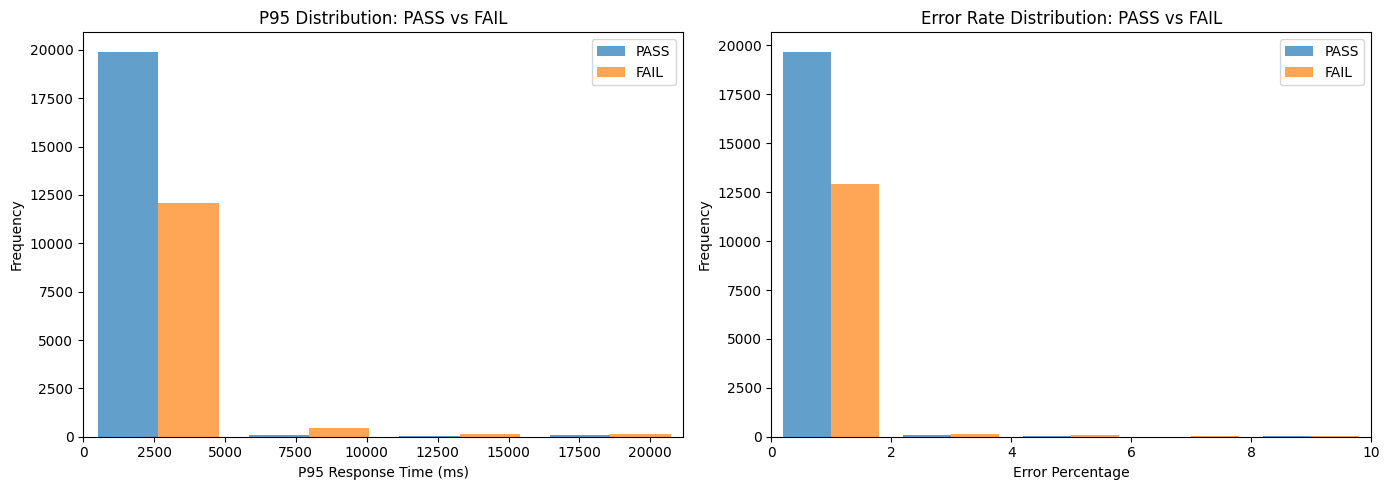


📊 Charts generated! Ask LLM to interpret:
ask_question('What do these distributions tell us about PASS vs FAIL tests?')


In [24]:
# Plot: P95 distribution by result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P95 by result
pass_data = df[df['exit_code'] == 1]['perc_95']
fail_data = df[df['exit_code'] != 1]['perc_95']

axes[0].hist([pass_data, fail_data], bins=50, label=['PASS', 'FAIL'], alpha=0.7)
axes[0].set_xlabel('P95 Response Time (ms)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P95 Distribution: PASS vs FAIL')
axes[0].legend()
axes[0].set_xlim(0, pass_data.quantile(0.99))

# Error percentage by result
pass_err = df[df['exit_code'] == 1]['error_percentage']
fail_err = df[df['exit_code'] != 1]['error_percentage']

axes[1].hist([pass_err, fail_err], bins=50, label=['PASS', 'FAIL'], alpha=0.7)
axes[1].set_xlabel('Error Percentage')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Error Rate Distribution: PASS vs FAIL')
axes[1].legend()
axes[1].set_xlim(0, 10)  # Focus on 0-10% range

plt.tight_layout()
plt.show()

print("\n📊 Charts generated! Ask LLM to interpret:")
print("ask_question('What do these distributions tell us about PASS vs FAIL tests?')")

## 12. Export Conversation

Save your Q&A session for reference.

In [25]:
# Export conversation history
if conversation_history:
    print("💬 Conversation Summary:")
    print("=" * 80)
    
    for i, (question, answer) in enumerate(conversation_history, 1):
        print(f"\n**Q{i}:** {question}")
        print(f"**A{i}:** {answer[:500]}{'...' if len(answer) > 500 else ''}")
        print("-" * 80)
    
    print(f"\nTotal questions asked: {len(conversation_history)}")
else:
    print("No conversation history yet. Ask some questions first!")

💬 Conversation Summary:

**Q1:** What are the last 5 test runs and their results?
**A1:** Here are the last 5 test runs and their results:

| Test Name                  | P95   | Errors  | Txns | Result | End Time                        |
|----------------------------|-------|---------|------|--------|----------------------------------|
| LoadTest_20260304T060726Z  | 662ms | 0.0%    | 54   | PASS   | 2026-03-03 23:09:31.482435-08:00|
| LoadTest_20260302T113608Z  | 710ms | 0.0%    | 54   | PASS   | 2026-03-02 04:38:24.516272-08:00|
| LoadTest_20260302T051326Z  | 673ms | 0.0%    | 54  ...
--------------------------------------------------------------------------------

**Q2:** What patterns do you see in failed tests?
**A2:** Here are the last 10 failed test runs:

| Test Name                  | P95     | Errors  | Txns | Result | End Time                        |
|----------------------------|---------|---------|------|--------|----------------------------------|
| LoadTest_20251029T235

## 10. Tips & Tricks

**Good Questions to Ask:**
- "What's the average P95 for transaction X?"
- "Show me tests where error rate > 5%"
- "How does transaction Y compare between PASS and FAIL tests?"
- "What are common characteristics of failed tests?"
- "Is there a trend in test performance over time?"
- "Which transactions have the highest variance?"

**For Follow-up Questions:**
- The conversation history is maintained
- Previous context helps with follow-ups
- You can ask "Why?" or "Explain more" for clarification

**Data Manipulation:**
- Use pandas to filter/aggregate data
- Pass results to `ask_question()` for LLM interpretation
- Combine visualizations with LLM insights